## Load google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Membuat folder pada google drive untuk menampung unduhan dataset

Cukup jalankan sekali saja.
Tidak perlu dijalankan lagi jika unduhan di bawah sudah pernah selesai

In [2]:
import os
save_path = "/content/drive/MyDrive/dataset_echonet"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## Mengunduh dataset echonet dan menyimpannya di folder google drive yang sudah dibuat sebelumnya

In [3]:
%cd /content/drive/MyDrive/dataset_echonet
!wget -c --user=oradi --ask-password -O echonext.zip "https://physionet.org/content/echonext/get-zip/1.1.0/"

/content/drive/MyDrive/dataset_echonet
Password for user ‘oradi’: 
--2026-08-11 06:08:04--  https://physionet.org/content/echonext/get-zip/1.1.0/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



## Menyalin echonet pada google drive ke google colab

In [4]:
!cp /content/drive/MyDrive/dataset_echonet/echonext.zip /content/echonext.zip

## Mengekstrak/unzip file echonet.zip supaya bisa digunakan

In [5]:
!unzip -q /content/echonext.zip -d /content/dataset_lokal

## Inisialisasi & Cek Data

In [6]:
import pandas as pd
import numpy as np
import os

# 1. Load Metadata
csv_path = '/content/dataset_lokal/echonext-a-dataset-for-detecting-echocardiogram-confirmed-structural-heart-disease-from-ecgs-1.1.0/echonext_metadata_100k.csv'
df = pd.read_csv(csv_path)

# 2. Filtering kriteria HFrEF (<=40) dan HFpEF (>=50)
df_train = df[df['split'] == 'train'].copy()

def label_hf(lvef):
    if lvef <= 40.0:
        return 0 # HFrEF
    elif lvef >= 50.0:
        return 1 # HFpEF
    else:
        return -1 # Kita buang yang di antara 40-50

df_train['label'] = df_train['lvef_value'].apply(label_hf)

# Hapus data yang tidak masuk kategori (LVEF 41-49)
df_final = df_train[df_train['label'] != -1].reset_index()

print(f"Total data train awal: {len(df_train)}")
print(f"Total data setelah filter (HFrEF/HFpEF): {len(df_final)}")
print(f"Distribusi Kelas:\n{df_final['label'].value_counts()}")

# 3. Inisialisasi Memory Map untuk File 16GB
waveform_path = '/content/dataset_lokal/echonext-a-dataset-for-detecting-echocardiogram-confirmed-structural-heart-disease-from-ecgs-1.1.0/EchoNext_train_waveforms.npy'

# 'r' artinya read-only, mmap_mode membuat file tidak masuk RAM sekaligus
try:
    waveforms_mmap = np.load(waveform_path, mmap_mode='r')
    print(f"\nBerhasil memetakan waveform!")
    print(f"Shape array di disk: {waveforms_mmap.shape}")

    # Tes akses satu data (indeks ke-0)
    sample_ecg = waveforms_mmap[0]
    print(f"Berhasil mengambil sampel. Shape per EKG: {sample_ecg.shape}")
except Exception as e:
    print(f"Error: {e}")

# Simpan df_final untuk digunakan di fase berikutnya
# df_final.to_csv('metadata_filtered.csv', index=False)

Total data train awal: 72475
Total data setelah filter (HFrEF/HFpEF): 61149
Distribusi Kelas:
label
1    46949
0    14200
Name: count, dtype: int64

Berhasil memetakan waveform!
Shape array di disk: (72475, 1, 2500, 12)
Berhasil mengambil sampel. Shape per EKG: (1, 2500, 12)


## Visualisasi & Eksperimen CWT

In [7]:
!pip install PyWavelets

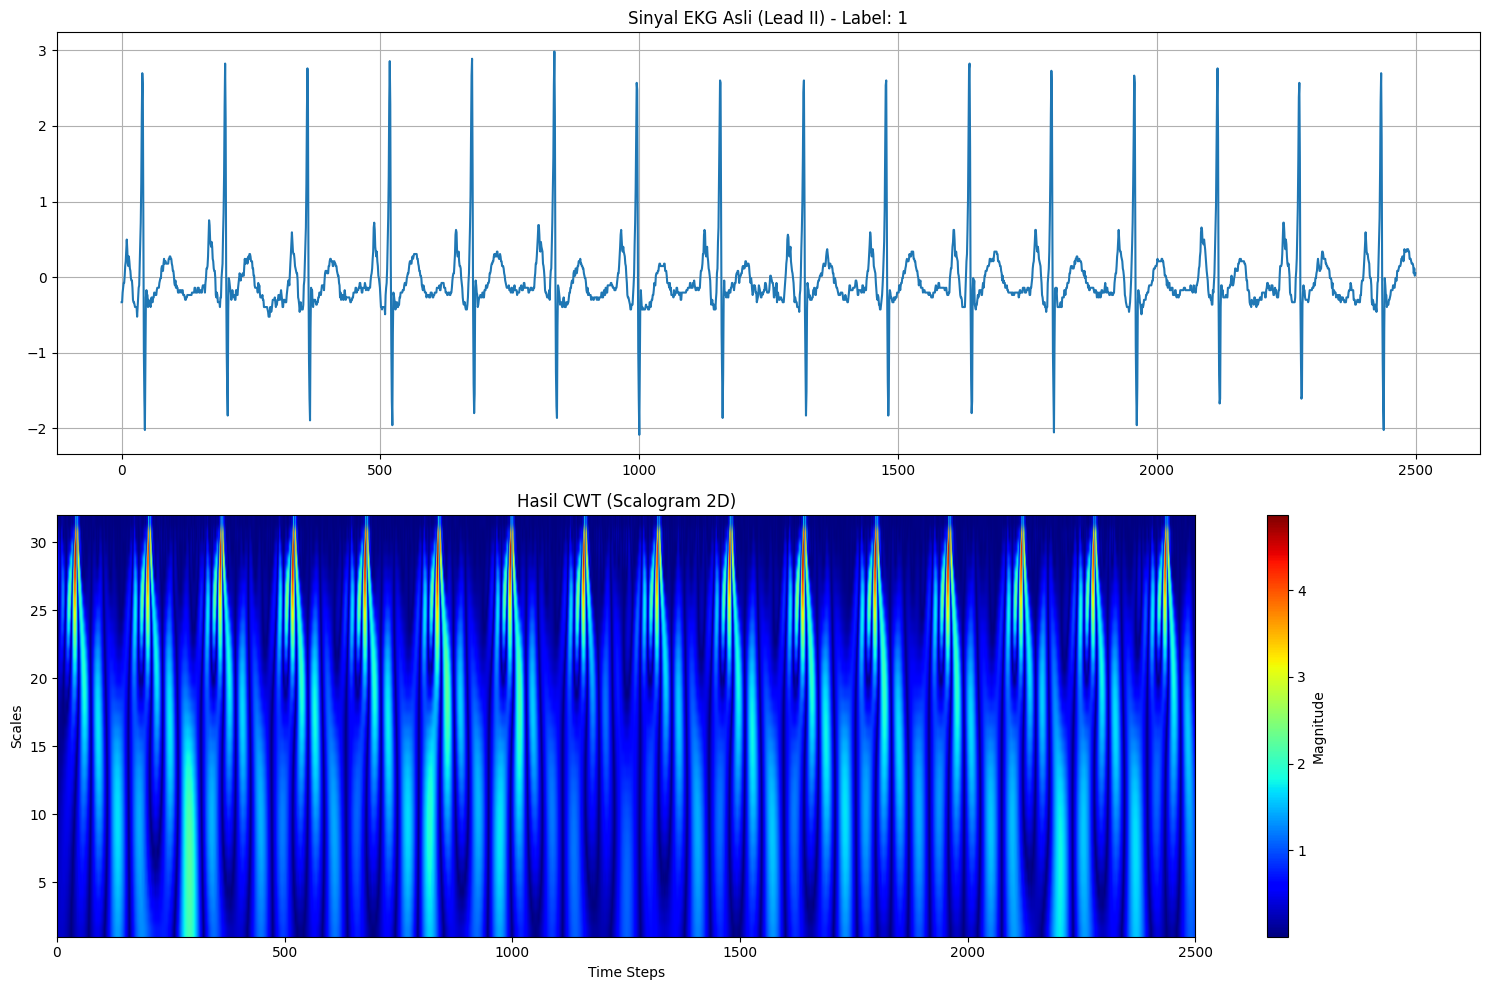

Shape matriks CWT: (32, 2500)


In [8]:
import pywt
import matplotlib.pyplot as plt

def apply_cwt_single_lead(signal, scales=np.arange(1, 31), wavelet='mexh'):
    # signal shape expected: (2500,)
    coef, freqs = pywt.cwt(signal, scales, wavelet)
    return coef

# 1. Ambil 1 sampel dari data yang sudah difilter (misal indeks ke-10)
idx_to_test = df_final.index[10]
sample_waveform = waveforms_mmap[idx_to_test].squeeze() # Hasilnya (2500, 12)

# 2. Kita coba CWT pada Lead II (indeks ke-1 dalam 12 lead)
# Lead II biasanya paling jelas untuk melihat ritme jantung
lead_ii_signal = sample_waveform[:, 1]
scales = np.arange(1, 33) # 32 scales (akan jadi tinggi gambar)
cwt_matrix = apply_cwt_single_lead(lead_ii_signal, scales)

# 3. Visualisasi Perbandingan
plt.figure(figsize=(15, 10))

# Sinyal EKG Asli
plt.subplot(2, 1, 1)
plt.plot(lead_ii_signal)
plt.title(f"Sinyal EKG Asli (Lead II) - Label: {df_final.iloc[10]['label']}")
plt.grid(True)

# Hasil CWT (Scalogram)
plt.subplot(2, 1, 2)
plt.imshow(np.abs(cwt_matrix), extent=[0, 2500, 1, 32], cmap='jet', aspect='auto')
plt.title("Hasil CWT (Scalogram 2D)")
plt.ylabel("Scales")
plt.xlabel("Time Steps")
plt.colorbar(label="Magnitude")

plt.tight_layout()
plt.show()

print(f"Shape matriks CWT: {cwt_matrix.shape}")

## Data Generator & Class Weights

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf

# 1. Split Data (Train & Validation)
# Kita pakai 80% train, 20% val
train_indices, val_indices = train_test_split(
    df_final.index, test_size=0.2, stratify=df_final['label'], random_state=42
)

# 2. Hitung Class Weights (Karena data tidak seimbang)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_final['label']),
    y=df_final['label']
)
class_weights_dict = dict(enumerate(weights))
print(f"Class Weights: {class_weights_dict}")

# 3. Custom Data Generator
class EKGGenerator(tf.keras.utils.Sequence):
    def __init__(self, indices, dataframe, mmap_data, batch_size=16, scales=np.arange(1, 33), leads=[0, 1, 10]):
        self.indices = indices
        self.df = dataframe
        self.mmap_data = mmap_data
        self.batch_size = batch_size
        self.scales = scales
        self.leads = leads # Lead I, II, dan V5

    def __len__(self):
        return int(np.floor(len(self.indices) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]

        X = []
        y = []

        for idx in batch_idx:
            # Ambil data EKG asli dari mmap (disk)
            # Urutan di df_final['index'] adalah index asli di file npy
            original_idx = self.df.loc[idx, 'index']
            signal = self.mmap_data[original_idx].squeeze() # (2500, 12)

            # CWT untuk lead terpilih
            cwt_leads = []
            for l in self.leads:
                coef, _ = pywt.cwt(signal[:, l], self.scales, 'mexh')
                cwt_leads.append(np.abs(coef))

            # Gabungkan lead sebagai channel (seperti gambar RGB tapi 3 lead)
            # Shape: (32, 2500, 3)
            X.append(np.stack(cwt_leads, axis=-1))
            y.append(self.df.loc[idx, 'label'])

        return np.array(X), np.array(y)

# Inisialisasi Generator
train_gen = EKGGenerator(train_indices, df_final, waveforms_mmap, batch_size=16)
val_gen = EKGGenerator(val_indices, df_final, waveforms_mmap, batch_size=16)

# Tes satu batch
X_test, y_test = train_gen[0]
print(f"\nBatch sample shape (X): {X_test.shape}") # Harus (16, 32, 2500, 3)
print(f"Batch sample shape (y): {y_test.shape}")

Class Weights: {0: np.float64(2.1531338028169014), 1: np.float64(0.651227928177384)}

Batch sample shape (X): (16, 32, 2500, 3)
Batch sample shape (y): (16,)


## Membangun Arsitektur CNN.

In [10]:
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential([
        # Block 1: Menangkap pola lokal
        layers.Conv2D(32, (3, 7), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 4)),

        # Block 2: Menangkap pola yang lebih luas
        layers.Conv2D(64, (3, 5), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 4)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 4)),

        # Global Pooling & Output
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid') # Sigmoid untuk binary classification
    ])

    return model

# 1. Inisialisasi Model
input_shape = (32, 2500, 3)
model = build_model(input_shape)

# 2. Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

# 3. Uji Coba Training (Hanya 1 Epoch dulu untuk tes kecepatan)
print("\nMemulai uji coba training (1 Epoch)...")
history = model.fit(
    train_gen,
    steps_per_epoch=20, # Kita batasi cuma 20 batch untuk tes awal
    validation_data=val_gen,
    validation_steps=5,
    class_weight=class_weights_dict,
    epochs=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 2494, 32)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 2494, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 623, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 619, 64)    │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 619, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 154, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 152, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 152, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 38, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,905 (452.75 KB)

 Trainable params: 115,457 (451.00 KB)

 Non-trainable params: 448 (1.75 KB)


Memulai uji coba training (1 Epoch)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 602ms/step - accuracy: 0.5938 - auc: 0.5386 - loss: 0.8517 - val_accuracy: 0.2500 - val_auc: 0.7233 - val_loss: 1.3998


## Full Training dengan Callbacks

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import pywt

# 1. Perbaikan Generator (Menambahkan super().__init__)
class EKGGenerator(tf.keras.utils.Sequence):
    def __init__(self, indices, dataframe, mmap_data, batch_size=16, scales=np.arange(1, 33), leads=[0, 1, 10], **kwargs):
        super().__init__(**kwargs) # Ini untuk menghilangkan warning
        self.indices = indices
        self.df = dataframe
        self.mmap_data = mmap_data
        self.batch_size = batch_size
        self.scales = scales
        self.leads = leads

    def __len__(self):
        return int(np.floor(len(self.indices) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        X, y = [], []
        for idx in batch_idx:
            original_idx = self.df.loc[idx, 'index']
            signal = self.mmap_data[original_idx].squeeze()
            cwt_leads = [np.abs(pywt.cwt(signal[:, l], self.scales, 'mexh')[0]) for l in self.leads]
            X.append(np.stack(cwt_leads, axis=-1))
            y.append(self.df.loc[idx, 'label'])
        return np.array(X), np.array(y)

# Re-inisialisasi generator
train_gen = EKGGenerator(train_indices, df_final, waveforms_mmap, batch_size=16)
val_gen = EKGGenerator(val_indices, df_final, waveforms_mmap, batch_size=16)

# 2. Callbacks: Biar model nggak 'tersesat'
callbacks = [
    # Berhenti kalau val_auc nggak naik dalam 3 epoch
    EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max'),
    # Turunkan learning rate kalau macet
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001),
    # Simpan model terbaik
    ModelCheckpoint('best_echonext_model.keras', monitor='val_auc', save_best_only=True, mode='max')
]

# 3. Training Sebenarnya
print("Memulai Full Training...")
history = model.fit(
    train_gen,
    epochs=15,#Pengulangan training.
    validation_data=val_gen,
    # Kita ambil 500 steps per epoch (~40 menit per epoch) biar nggak terlalu lama
    steps_per_epoch=500,
    validation_steps=100,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Memulai Full Training...
Epoch 1/15
430/500 ━━━━━━━━━━━━━━━━━━━━ 28s 400ms/step - accuracy: 0.6563 - auc: 0.6987 - loss: 0.6617

## Evaluasi (COnfusion Matrix)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Mengumpulkan prediksi dan label asli dari validation generator
# Kita akan mengambil beberapa batch dari val_gen untuk evaluasi
num_batches_to_eval = 100
y_true = []
y_pred = []

print(f"Mengevaluasi {num_batches_to_eval} batch dari data validasi...")

for i in range(num_batches_to_eval):
    X_batch, y_batch = val_gen[i]
    preds = model.predict(X_batch, verbose=0)

    y_true.extend(y_batch)
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Membuat Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['HFrEF (<=40)', 'HFpEF (>=50)']

# 3. Visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - EchoNext Classification')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

# 4. Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

In [ ]:
# 1. Simpan model secara lokal di environment Colab
model_filename = 'echonext_final_model.keras'
model.save(model_filename)
print(f"Model berhasil disimpan sebagai {model_filename}")

# 2. Opsional: Download model ke komputer lokal
from google.colab import files
try:
    files.download(model_filename)
    print("Memulai unduhan model...")
except Exception as e:
    print(f"Gagal mendownload otomatis: {e}")
    print("Anda bisa mendownload manual lewat sidebar folder di sebelah kiri.")

In [ ]:
import matplotlib.pyplot as plt

# Memvisualisasikan Grafik AUC (Training vs Validation)
def plot_auc(history_obj):
    # Mengambil data dari objek history
    auc = history_obj.history['auc']
    val_auc = history_obj.history['val_auc']
    epochs = range(1, len(auc) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, auc, 'bo-', label='Training AUC')
    plt.plot(epochs, val_auc, 'ro-', label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)
    plt.show()

# Mengecek apakah variabel 'history' ada di namespace global
if 'history' in globals():
    print("Riwayat pelatihan ditemukan, membuat grafik...")
    plot_auc(history)
else:
    print("Error: Variabel 'history' tidak ditemukan.")
    print("Pastikan Anda telah menjalankan cell pelatihan (fit) dan variabel 'history = model.fit(...)' telah terdefinisi.")